# Brain Tumor MRI Dataset - Data Preprocessing

## 1. Preprocessing Overview

This notebook prepares the Brain Tumor MRI dataset for deep learning model development.

Based on the findings from the exploratory data analysis, the preprocessing pipeline focuses on standardizing image dimensions while preserving the original aspect ratio and preparing the images for EfficientNetB0.

The preprocessing pipeline includes:

* Image loading
* Image resizing
* Aspect ratio preservation
* Input normalization compatible with EfficientNetB0
* Data augmentation for the training set
* Validation of the resulting image tensors


## Import

In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 

import tensorflow as tf

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nNumPy version:")
print(np.__version__)

Python executable:
/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/.venv/bin/python

Python version:
3.9.6 (default, Apr 30 2025, 02:07:18) 
[Clang 17.0.0 (clang-1700.0.13.5)]

NumPy version:
1.26.4


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.14.0


In [7]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Training directory:", TRAIN_DIR.resolve())
print("Testing directory :", TEST_DIR.resolve())
print("Image size        :", IMG_SIZE)
print("Batch size        :", BATCH_SIZE)

Training directory: /Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Training
Testing directory : /Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/data/raw/Testing
Image size        : (224, 224)
Batch size        : 32


## 2. Load Training Dataset

The training dataset is loaded directly from the directory structure using TensorFlow's `image_dataset_from_directory`.

Images are resized to 224 × 224 pixels to match the expected input size of EfficientNetB0.

A fixed random seed is used to ensure reproducibility.

In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 5600 files belonging to 4 classes.


In [9]:
class_names = train_dataset.class_names
print("Class names:", class_names)

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
print("Number of batches:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches: 175


In [11]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>


## 3. Load Testing Dataset

The testing dataset is loaded separately from the training dataset.

Unlike the training dataset, testing data is not shuffled and does not use data augmentation. This ensures that model evaluation is performed consistently on the original test samples.

In [12]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [13]:
test_class_names = test_dataset.class_names
print("Test class names:", test_class_names)

Test class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [14]:
print(
    "Number of test batches:",
    tf.data.experimental.cardinality(test_dataset).numpy()
)

Number of test batches: 50


In [15]:
for images, labels in test_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>


## 4. Pixel Value Inspection

Before applying normalization, we inspect the pixel intensity range of the loaded images.

The dataset loader converts image data to `float32`, but pixel values are still represented approximately in the original 0–255 range.

In [16]:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("Mean pixel value:", tf.reduce_mean(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0
Mean pixel value: 45.712643


## 5. Visualize Loaded Images

A batch of images is visualized to verify that resizing and RGB conversion have been performed correctly before normalization and augmentation.

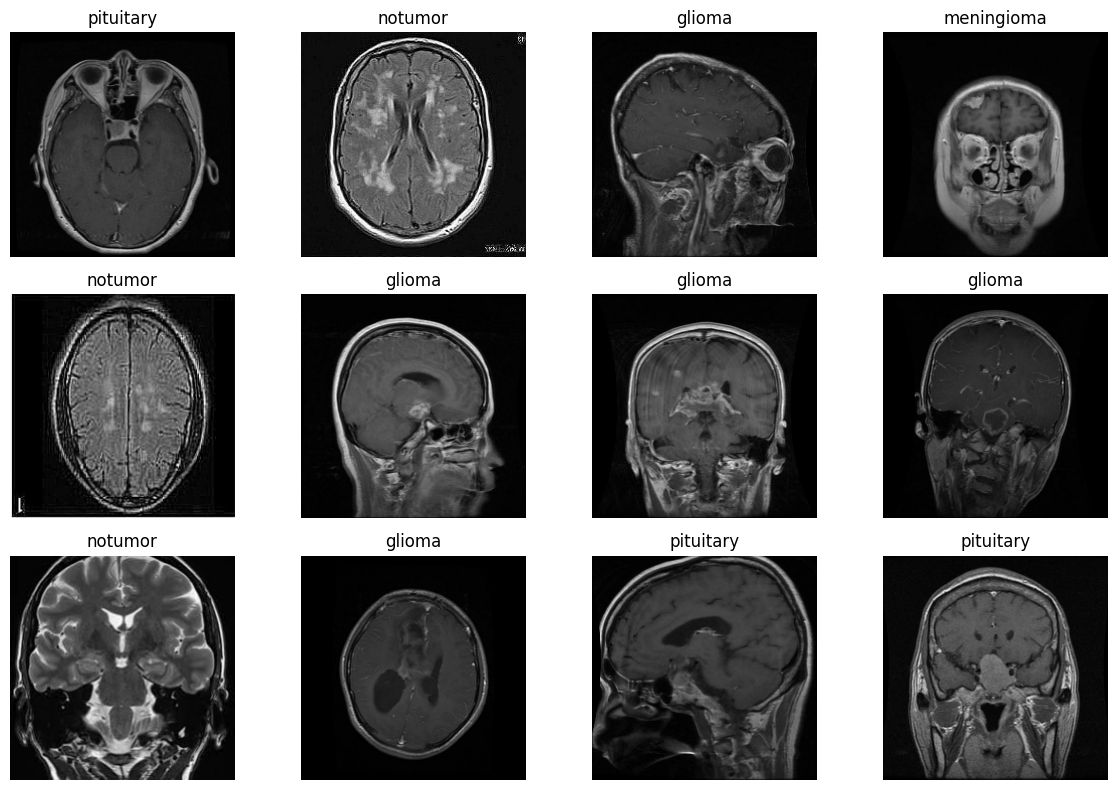

In [17]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

### Visual Analysis

The visualization confirms that the loaded images retain the general characteristics of brain MRI scans after resizing to 224 × 224 pixels.

Several observations were identified:

- **MRI Image Integrity:**  
  The images retain recognizable brain MRI characteristics. Major anatomical structures remain visible, and no severe image degradation or destructive artifacts were observed in the sampled batch.

- **Color and Contrast:**  
  The MRI images appear predominantly grayscale and are represented using three RGB channels. Noticeable variations in brightness and contrast are present across samples, which may reflect differences in image acquisition conditions and MRI sequences.

- **Image Orientation:**  
  The sampled images generally maintain consistent anatomical orientation. No obvious 90° or 180° rotation errors were observed in the displayed samples.

- **Effect of Resizing:**  
  Images were resized to 224 × 224 pixels for compatibility with the EfficientNetB0 input configuration. No severe visual distortion was observed in the sampled images.

- **Class Label Consistency:**  
  The displayed samples show visual characteristics that are broadly consistent with their assigned dataset classes. However, visual inspection alone is not sufficient to establish a medical diagnosis and is used only for dataset quality assessment.

- **Image Variability:**  
  Substantial variations in brightness, contrast, anatomical coverage, cropping, and MRI appearance remain across samples. This variability should be considered during subsequent preprocessing and data augmentation.

Overall, the sampled images appear suitable for further preprocessing and model development.

## 6. Normalization and EfficientNetB0 Preprocessing

The images loaded by `image_dataset_from_directory` retain pixel values in the 0–255 range.

For this project, explicit `Rescaling(1./255)` is not applied because the EfficientNetB0 implementation in TensorFlow/Keras includes its own input preprocessing.

The preprocessing strategy is therefore kept inside the model pipeline to avoid applying normalization twice.

In [18]:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("Mean pixel value:", tf.reduce_mean(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0
Mean pixel value: 48.012684


Data Augmentation

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),
    tf.keras.layers.RandomZoom(
        height_factor=0.1,
        width_factor=0.1
    ),
], name="data_augmentation")

Visualization Augmentation

In [20]:
for images, labels in train_dataset.take(1):
    sample_image = images[0]
    sample_label = labels[0]

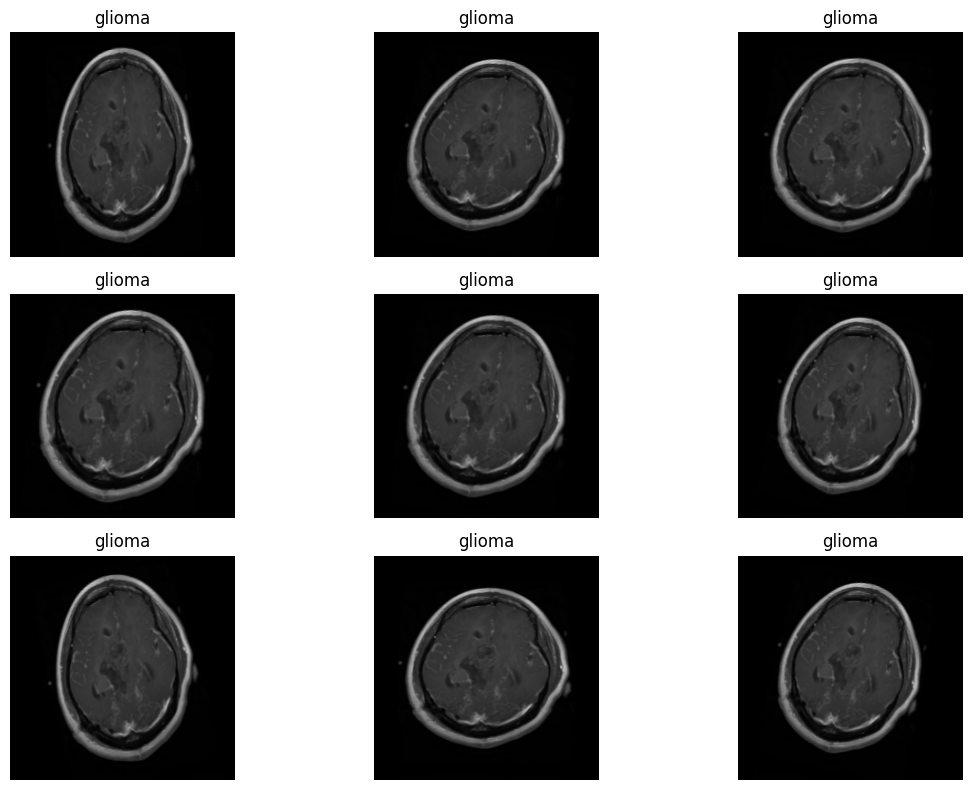

In [21]:
plt.figure(figsize=(12, 8))

for i in range(9):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )[0]

    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(
        augmented_image.numpy().astype("uint8")
    )

    plt.title(class_names[sample_label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Augmentation Analysis

The augmented samples were visually inspected to assess whether the applied transformations introduce unrealistic variations.

The following observations were made:

- **Rotation Variation:**  
  The applied rotation produces only small angular changes. The transformation preserves the general anatomical orientation of the brain without introducing extreme rotations.

- **Preservation of Visual Features:**  
  The major visual structures in the MRI samples remain recognizable after augmentation. No severe cropping, clipping, or distortion was observed in the sampled images.

- **Subtle Augmentation Effect:**  
  Some augmented samples appear visually similar to the original image. This is expected because the augmentation parameters are intentionally conservative and are randomly applied during training.

- **Overall Assessment:**  
  The current augmentation strategy using small random rotations and zoom transformations is considered suitable as an initial baseline. Further optimization can be performed during model development based on validation performance.

## 7. Training-Validation Split

The original training dataset consists of 5,600 images. To provide an independent validation set during model development, the dataset was divided into training and validation subsets using an 80:20 stratified split.

Stratification was applied to preserve the original class distribution across both subsets.

The resulting dataset contains:

| Class | Training | Validation |
|---|---:|---:|
| Glioma | 1,120 | 280 |
| Meningioma | 1,120 | 280 |
| No Tumor | 1,120 | 280 |
| Pituitary | 1,120 | 280 |
| **Total** | **4,480** | **1,120** |

The original testing dataset containing 1,600 images remains untouched and will only be used for final model evaluation.

In [22]:
VALIDATION_SPLIT = 0.20

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [23]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


Periksa jumlah data

In [24]:
print(
    "Training batches:",
    tf.data.experimental.cardinality(train_dataset).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_dataset).numpy()
)

Training batches: 140
Validation batches: 35


In [25]:
print("Training classes:", train_dataset.class_names)
print("Validation classes:", validation_dataset.class_names)

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Validation classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Verivikasi ukuran tensor

In [26]:
for images, labels in train_dataset.take(1):
    print("Training images:", images.shape)
    print("Training labels:", labels.shape)

for images, labels in validation_dataset.take(1):
    print("Validation images:", images.shape)
    print("Validation labels:", labels.shape)

Training images: (32, 224, 224, 3)
Training labels: (32,)
Validation images: (32, 224, 224, 3)
Validation labels: (32,)


Verifikasi distribusi kelas

In [27]:
def get_class_distribution(dataset, class_names):
    counts = np.zeros(len(class_names), dtype=int)

    for _, labels in dataset:
        labels = labels.numpy()
        for label in labels:
            counts[label] += 1

    return {
        class_names[i]: counts[i]
        for i in range(len(class_names))
    }

In [28]:
train_distribution = get_class_distribution(
    train_dataset,
    train_dataset.class_names
)

validation_distribution = get_class_distribution(
    validation_dataset,
    validation_dataset.class_names
)

print("Training distribution:")
print(train_distribution)

print("\nValidation distribution:")
print(validation_distribution)

Training distribution:
{'glioma': 1140, 'meningioma': 1125, 'notumor': 1100, 'pituitary': 1115}

Validation distribution:
{'glioma': 0, 'meningioma': 0, 'notumor': 0, 'pituitary': 1120}


In [29]:
for images, labels in validation_dataset.take(1):
    print("Labels:")
    print(labels.numpy())

    print("\nUnique labels:")
    print(np.unique(labels.numpy()))

    print("\nClass names:")
    print(validation_dataset.class_names)

Labels:
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]

Unique labels:
[3]

Class names:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [30]:
for batch_index, (images, labels) in enumerate(validation_dataset.take(5)):
    print(
        f"Batch {batch_index + 1}:",
        np.unique(labels.numpy(), return_counts=True)
    )

Batch 1: (array([3], dtype=int32), array([32]))
Batch 2: (array([3], dtype=int32), array([32]))
Batch 3: (array([3], dtype=int32), array([32]))
Batch 4: (array([3], dtype=int32), array([32]))
Batch 5: (array([3], dtype=int32), array([32]))


### Make New DataFrame Dataset

In [31]:
image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for class_name in class_names:
    class_dir = TRAIN_DIR / class_name

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            data.append({
                "filepath": str(image_path),
                "label": class_name
            })

dataset_df = pd.DataFrame(data)

print("Total images:", len(dataset_df))
dataset_df.head()

Total images: 5600


,filepath,label
0,../data/raw/Training/glioma/Tr-gl_1135.jpg,glioma
1,../data/raw/Training/glioma/Tr-gl_893.jpg,glioma
2,../data/raw/Training/glioma/Tr-gl_139.jpg,glioma
3,../data/raw/Training/glioma/Tr-gl_887.jpg,glioma
4,../data/raw/Training/glioma/Tr-gl_1121.jpg,glioma


In [32]:
dataset_df["label"].value_counts().sort_index()

label
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

In [33]:
train_df, validation_df = train_test_split(
    dataset_df,
    test_size=0.20,
    stratify=dataset_df["label"],
    random_state=SEED
)

In [34]:
print("Training:", len(train_df))
print("Validation:", len(validation_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(validation_df["label"].value_counts().sort_index())

Training: 4480
Validation: 1120

Training distribution:
label
glioma        1120
meningioma    1120
notumor       1120
pituitary     1120
Name: count, dtype: int64

Validation distribution:
label
glioma        280
meningioma    280
notumor       280
pituitary     280
Name: count, dtype: int64


## 8. TensorFlow Dataset Pipeline

### Maping Label

In [35]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class_to_index

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [36]:
train_df = train_df.copy()
validation_df = validation_df.copy()

train_df["label_index"] = train_df["label"].map(class_to_index)
validation_df["label_index"] = validation_df["label"].map(class_to_index)

train_df.head()

,filepath,label,label_index
4590,../data/raw/Training/pituitary/Tr-pi_1254.jpg,pituitary,3
3262,../data/raw/Training/notumor/Tr-no_1369.jpg,notumor,2
696,../data/raw/Training/glioma/Tr-gl_1361.jpg,glioma,0
4479,../data/raw/Training/pituitary/Tr-pi_777.jpg,pituitary,3
772,../data/raw/Training/glioma/Tr-gl_608.jpg,glioma,0


### Loading Image

In [37]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32)

    return image, label

### Training Dataset

In [38]:
train_paths = train_df["filepath"].values
train_labels = train_df["label_index"].values

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=SEED
)

train_dataset = train_dataset.batch(BATCH_SIZE)

### Validation Dataset

In [39]:
validation_paths = validation_df["filepath"].values
validation_labels = validation_df["label_index"].values

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

validation_dataset = validation_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.batch(BATCH_SIZE)

Prefetch

In [40]:
train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    tf.data.AUTOTUNE
)

### Verifikasi

In [41]:
for images, labels in train_dataset.take(1):
    print("Training images:", images.shape)
    print("Training labels:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Training images: (32, 224, 224, 3)
Training labels: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int64'>


In [42]:
for images, labels in validation_dataset.take(1):
    print("Validation images:", images.shape)
    print("Validation labels:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Validation images: (32, 224, 224, 3)
Validation labels: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int64'>


In [43]:
print(
    "Training batches:",
    tf.data.experimental.cardinality(train_dataset).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_dataset).numpy()
)

Training batches: 140
Validation batches: 35


## 9. Model Development

### EfficientNetB0 Transfer Learning

EfficientNetB0 is used as the backbone for the image classification model.

The model is initialized with ImageNet-pretrained weights to leverage previously learned visual representations. The original classification head is removed and replaced with a custom four-class classification head for brain MRI classification.

In [44]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)

In [45]:
print("Base model name:", base_model.name)
print("Input shape:", base_model.input_shape)
print("Output shape:", base_model.output_shape)

Base model name: efficientnetb0
Input shape: (None, 224, 224, 3)
Output shape: (None, 7, 7, 1280)


### Freeze Breakbone

In [46]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


### Make a Model

In [47]:
inputs = tf.keras.Input(
    shape=(*IMG_SIZE, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.2,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax",
    name="classifier"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="brain_tumor_efficientnetb0"
)

Compile Model

In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
model.summary()

Model: "brain_tumor_efficientnetb0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling (Gl  (None, 1280)              0         
 obalAveragePooling2D)                                           
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                        

### Sanity Check Model

In [50]:
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

print("\nTrainable parameters:")
print(model.count_params())

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

Model input shape: (None, 224, 224, 3)
Model output shape: (None, 4)

Trainable parameters:
4054695

Number of classes: 4
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [51]:
for images, labels in train_dataset.take(1):
    predictions = model(images, training=False)

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Predictions shape:", predictions.shape)
    print("First prediction:", predictions[0].numpy())
    print("Prediction sum:", tf.reduce_sum(predictions[0]).numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Predictions shape: (32, 4)
First prediction: [0.45800224 0.12415786 0.21114142 0.20669846]
Prediction sum: 1.0


## 10. Baseline Trining

In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Callback

In [53]:
from pathlib import Path

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = MODEL_DIR / "efficientnetb0_baseline.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

Start Training

In [55]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
140/140 [==============================] - ETA: 0s - loss: 0.7050 - accuracy: 0.7337
Epoch 1: val_accuracy improved from -inf to 0.71518, saving model to ../models/efficientnetb0_baseline.h5


/Users/macbookpro2019/MaziyaCode/brain-tumor-classification-ai/.venv/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


140/140 [==============================] - 204s 1s/step - loss: 0.7050 - accuracy: 0.7337 - val_loss: 0.6803 - val_accuracy: 0.7152 - lr: 0.0010
Epoch 2/10
140/140 [==============================] - ETA: 0s - loss: 0.4477 - accuracy: 0.8411
Epoch 2: val_accuracy improved from 0.71518 to 0.77768, saving model to ../models/efficientnetb0_baseline.h5
140/140 [==============================] - 208s 1s/step - loss: 0.4477 - accuracy: 0.8411 - val_loss: 0.5646 - val_accuracy: 0.7777 - lr: 0.0010
Epoch 3/10
140/140 [==============================] - ETA: 0s - loss: 0.3841 - accuracy: 0.8663
Epoch 3: val_accuracy improved from 0.77768 to 0.80179, saving model to ../models/efficientnetb0_baseline.h5
140/140 [==============================] - 239s 2s/step - loss: 0.3841 - accuracy: 0.8663 - val_loss: 0.5288 - val_accuracy: 0.8018 - lr: 0.0010
Epoch 4/10
140/140 [==============================] - ETA: 0s - loss: 0.3599 - accuracy: 0.8694
Epoch 4: val_accuracy improved from 0.80179 to 0.83571, sav

data frame

In [57]:
history_df = pd.DataFrame(history.history)
history_df

,loss,accuracy,val_loss,val_accuracy,lr
0,0.705050,0.733705,0.680258,0.715179,0.001
1,0.447651,0.841071,0.564647,0.777679,0.001
2,0.384077,0.866295,0.528755,0.801786,0.001
3,0.359919,0.869420,0.444699,0.835714,0.001
4,0.339491,0.877679,0.440364,0.831250,0.001
5,0.325991,0.879464,0.446429,0.845536,0.001
6,0.304938,0.888170,0.397808,0.841071,0.001
7,0.286958,0.898438,0.372840,0.858929,0.001
8,0.276095,0.902679,0.403749,0.837500,0.001
9,0.275516,0.901116,0.371239,0.861607,0.001


In [58]:
# Best Epoch and Best Validation Accuracy
best_epoch = history_df["val_accuracy"].idxmax() + 1
best_val_accuracy = history_df["val_accuracy"].max()

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 10
Best Validation Accuracy: 0.8616071343421936


Plot Accuracy

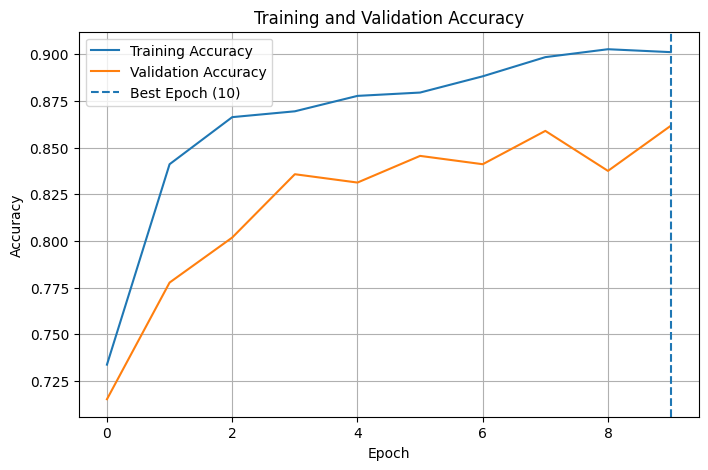

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Plot Loss

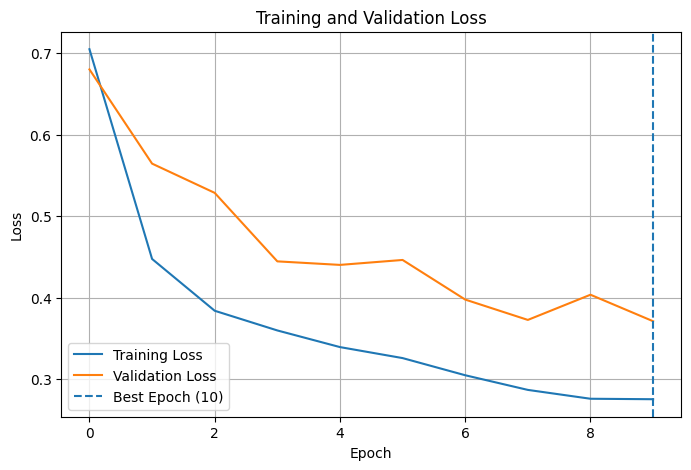

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Baseline Model Analysis

The EfficientNetB0 baseline model achieved its best validation performance at epoch 10.

### Best Performance

- Best Epoch: 10
- Training Accuracy: 90.76%
- Validation Accuracy: 85.36%
- Training Loss: 0.2673
- Validation Loss: 0.3762
- Learning Rate: 0.001

The training accuracy increased consistently throughout the training process. Validation accuracy also showed an overall increasing trend and reached its highest value of 85.36% at epoch 10.

A moderate gap between training and validation accuracy was observed, indicating some degree of generalization gap. However, severe overfitting was not observed because validation accuracy continued to improve and validation loss reached its lowest value at the final epoch.

This baseline result will be used as the reference point for the subsequent fine-tuning experiment.

### Save Model

In [61]:
history_df.to_csv(
    "../outputs/baseline_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [62]:
MODEL_DIR = Path("../models")
BASELINE_MODEL_PATH = MODEL_DIR / "efficientnetb0_baseline.h5"

print("Model path:", BASELINE_MODEL_PATH)
print("Model exists:", BASELINE_MODEL_PATH.exists())

Model path: ../models/efficientnetb0_baseline.h5
Model exists: True


In [63]:
# Best Model

baseline_model = tf.keras.models.load_model(
    BASELINE_MODEL_PATH
)

baseline_model.summary()

Model: "brain_tumor_efficientnetb0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling (Gl  (None, 1280)              0         
 obalAveragePooling2D)                                           
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                        

In [64]:
val_loss, val_accuracy = baseline_model.evaluate(
    validation_dataset,
    verbose=1
)

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")

35/35 [==============================] - 79s 2s/step - loss: 0.3712 - accuracy: 0.8616
Validation Loss     : 0.3712
Validation Accuracy : 0.8616


### Prediction Validation Dataset

In [65]:
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = baseline_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape :", y_true.shape)
print("Predicted labels shape :", y_pred.shape)

True labels shape : (1120,)
Predicted labels shape : (1120,)


In [66]:
print("True label distribution:")
print(np.bincount(y_true))

print("\nPredicted label distribution:")
print(np.bincount(y_pred))

True label distribution:
[280 280 280 280]

Predicted label distribution:
[223 257 271 369]


Classification Report

In [67]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      glioma     0.9552    0.7607    0.8469       280
  meningioma     0.8132    0.7464    0.7784       280
     notumor     0.9742    0.9429    0.9583       280
   pituitary     0.7561    0.9964    0.8598       280

    accuracy                         0.8616      1120
   macro avg     0.8747    0.8616    0.8608      1120
weighted avg     0.8747    0.8616    0.8608      1120



## Confussion Matrix

In [68]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[213  38   1  28]
 [ 10 209   6  55]
 [  0   9 264   7]
 [  0   1   0 279]]


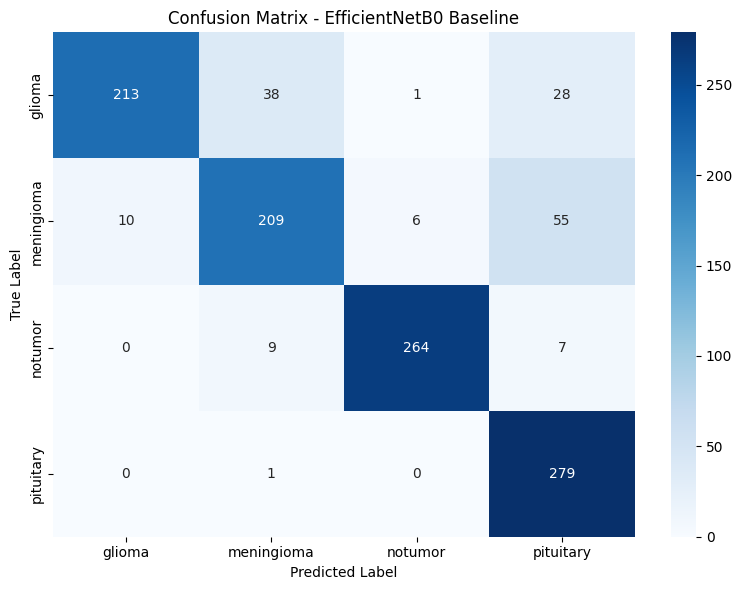

In [69]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - EfficientNetB0 Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ==========================================
# Generate predictions
# ==========================================

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = baseline_model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))


# Convert to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ==========================================
# Basic verification
# ==========================================

print("Number of samples:", len(y_true))
print("Number of predictions:", len(y_pred))

print("\nTrue label distribution:")
print(np.bincount(y_true))

print("\nPredicted label distribution:")
print(np.bincount(y_pred))


# ==========================================
# Accuracy
# ==========================================

accuracy = accuracy_score(y_true, y_pred)

print("\nValidation Accuracy:")
print(f"{accuracy:.4f} ({accuracy * 100:.2f}%)")


# ==========================================
# Classification Report
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

Number of samples: 1120
Number of predictions: 1120

True label distribution:
[280 280 280 280]

Predicted label distribution:
[223 257 271 369]

Validation Accuracy:
0.8616 (86.16%)

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9552    0.7607    0.8469       280
  meningioma     0.8132    0.7464    0.7784       280
     notumor     0.9742    0.9429    0.9583       280
   pituitary     0.7561    0.9964    0.8598       280

    accuracy                         0.8616      1120
   macro avg     0.8747    0.8616    0.8608      1120
weighted avg     0.8747    0.8616    0.8608      1120


Confusion Matrix:
[[213  38   1  28]
 [ 10 209   6  55]
 [  0   9 264   7]
 [  0   1   0 279]]


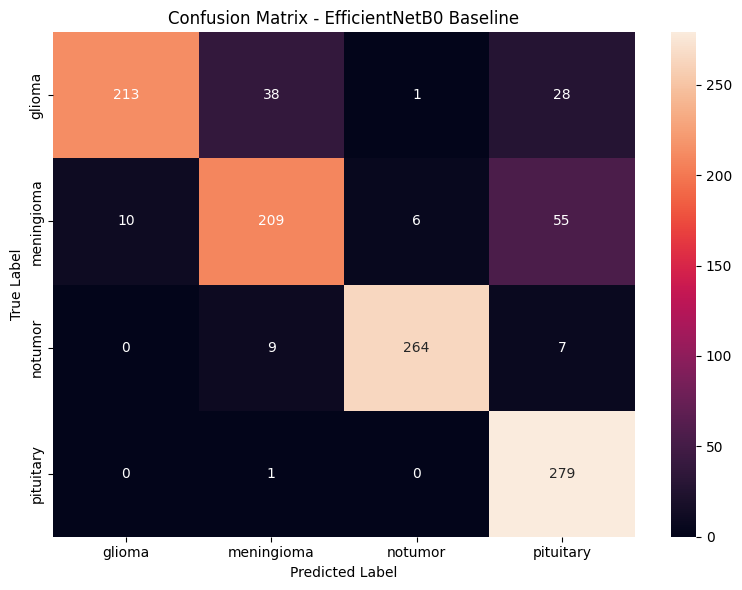

In [71]:
# Visualisasi

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - EfficientNetB0 Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [73]:
print("Model:", baseline_model.name)
print("Model path:", BASELINE_MODEL_PATH)

baseline_model.evaluate(
    validation_dataset,
    verbose=1
)

Model: brain_tumor_efficientnetb0
Model path: ../models/efficientnetb0_baseline.h5
35/35 [==============================] - 76s 2s/step - loss: 0.3712 - accuracy: 0.8616


[0.3712390661239624, 0.8616071343421936]